#Phase -1 : Data Preprocessing and EDA


In [ ]:
!pip install scikit-learn

In [ ]:
!pip install wordcloud

In [ ]:
#Importing the libraries
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px
import nltk
from sklearn.feature_extraction.text import CountVectorizer
from wordcloud import WordCloud, STOPWORDS
import re,string,unicodedata,warnings
from sklearn.metrics import classification_report,confusion_matrix,accuracy_score,f1_score
from sklearn.model_selection import train_test_split
from string import punctuation
from nltk import pos_tag
from nltk.corpus import wordnet

warnings.filterwarnings("ignore")

###Load the data

In [ ]:
%%time
df = pd.read_csv(r"/content/synthetic_emotions.csv")

CPU times: user 57.5 ms, sys: 2.97 ms, total: 60.5 ms
Wall time: 60.4 ms


In [ ]:
df.iloc[0, 0]

'As the sun dipped below the horizon, painting hues of orange and pink across the sky, John felt a profound sense of love wash over him. The gentle breeze rustled through the leaves, and he could hear the laughter of children playing nearby. In that moment, surrounded by the beauty of nature, he realized how deeply connected he was to those around him – his partner, his family, even the strangers passing by. His heart swelled with an overwhelming feeling of love, a testament to the powerful bond that unites us all.'

In [ ]:
df['emotion'].value_counts()

,count
emotion,
Anger,2000
Happiness,1999
Sad,1998
Hate,1998
Fun,1998
Love,1996
Surprise,1981


In [ ]:
#find the total no. of rows
len(df)

13970

In [ ]:
df.isnull().sum()

,0
text,0
emotion,0


###Data Cleaning and preprocessing

In [ ]:
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [ ]:
#customize stopword as per data
from nltk.corpus import stopwords
stop_words = set(stopwords.words('english'))
new_words = ["eye","john","rabbit"]
stop_words.update(new_words)


In [ ]:
!pip install contractions

In [ ]:
#defining helper functions for preprocessing
import re
import contractions

# 1. Expand contractions
def expand_text(content):
    # Use contractions.fix() on the string directly
    return contractions.fix(content)

# 2. Removing URLs
def remove_url(content):
    return re.sub(r'http\S+', '', content)

# 3. Removing specific special characters
def remove_special_character(content):
    # Added 'r' for raw string and removed extra backslash
    return re.sub(r'[{^$@&!*}[\]]', ' ', content)

# 4. Removing stopwords and non-alphabetic words
def remove_stopwords(content):
    clean_data = []
    for i in content.split():
        # strip() and lower() once for efficiency
        word = i.strip().lower()
        if word not in stop_words and word.isalpha():
            clean_data.append(word)
    return " ".join(clean_data) # Use single space


In [ ]:
#data preprocessing
def data_cleaning(content):
  content = remove_special_character(content)
  content = remove_url(content)
  content = expand_text(content)
  content = remove_stopwords(content)
  return content

In [ ]:
%%time
#data cleaning
df['text'] = df['text'].apply(data_cleaning)
df['text'].iloc[0]

CPU times: user 474 ms, sys: 4.02 ms, total: 478 ms
Wall time: 479 ms


'sun dipped painting hues orange pink across felt profound sense love wash gentle breeze rustled could hear laughter children playing surrounded beauty realized deeply connected around even strangers passing heart swelled overwhelming feeling testament powerful bond unites us'

In [ ]:
print('unique emotions is %s ' % df.emotion.nunique())
print('unique emotions are %s ' % df.emotion.unique())
print('unique emotions are %s ' % df.emotion.value_counts())

unique emotions is 7 
unique emotions are ['Love' 'Sad' 'Anger' 'Fun' 'Hate' 'Surprise' 'Happiness'] 
unique emotions are emotion
Anger        2000
Happiness    1999
Sad          1998
Hate         1998
Fun          1998
Love         1996
Surprise     1981
Name: count, dtype: int64 


In [ ]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df['emotion'] = le.fit_transform(df['emotion'])

# To see which number represents which emotion later:
mapping = dict(zip(le.classes_, le.transform(le.classes_)))
print(mapping)


{'Anger': np.int64(0), 'Fun': np.int64(1), 'Happiness': np.int64(2), 'Hate': np.int64(3), 'Love': np.int64(4), 'Sad': np.int64(5), 'Surprise': np.int64(6)}


###Exploratory Data Analysis

In [ ]:
df.head(3)

,text,emotion
0,sun dipped painting hues orange pink across fe...,4
1,gazed warm glow enveloped soft laughter echoin...,4
2,gazed heart fluttered overwhelming sense warmt...,4


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13970 entries, 0 to 13969
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   text     13970 non-null  object
 1   emotion  13970 non-null  int64 
dtypes: int64(1), object(1)
memory usage: 218.4+ KB


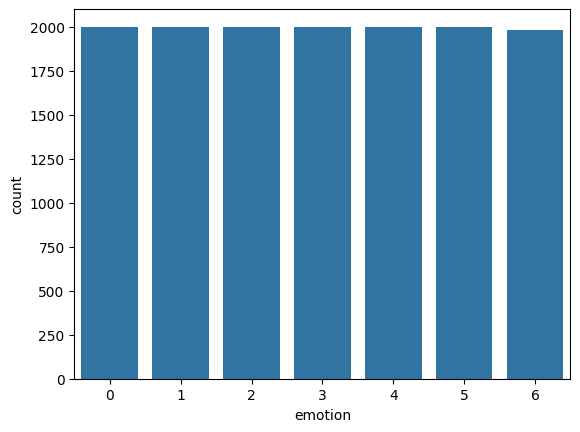

emotion
0    2000
2    1999
5    1998
3    1998
1    1998
4    1996
6    1981
Name: count, dtype: int64


In [ ]:
#check for class imbalance
sns.countplot(x=df['emotion'])
plt.show()
print(df['emotion'].value_counts())

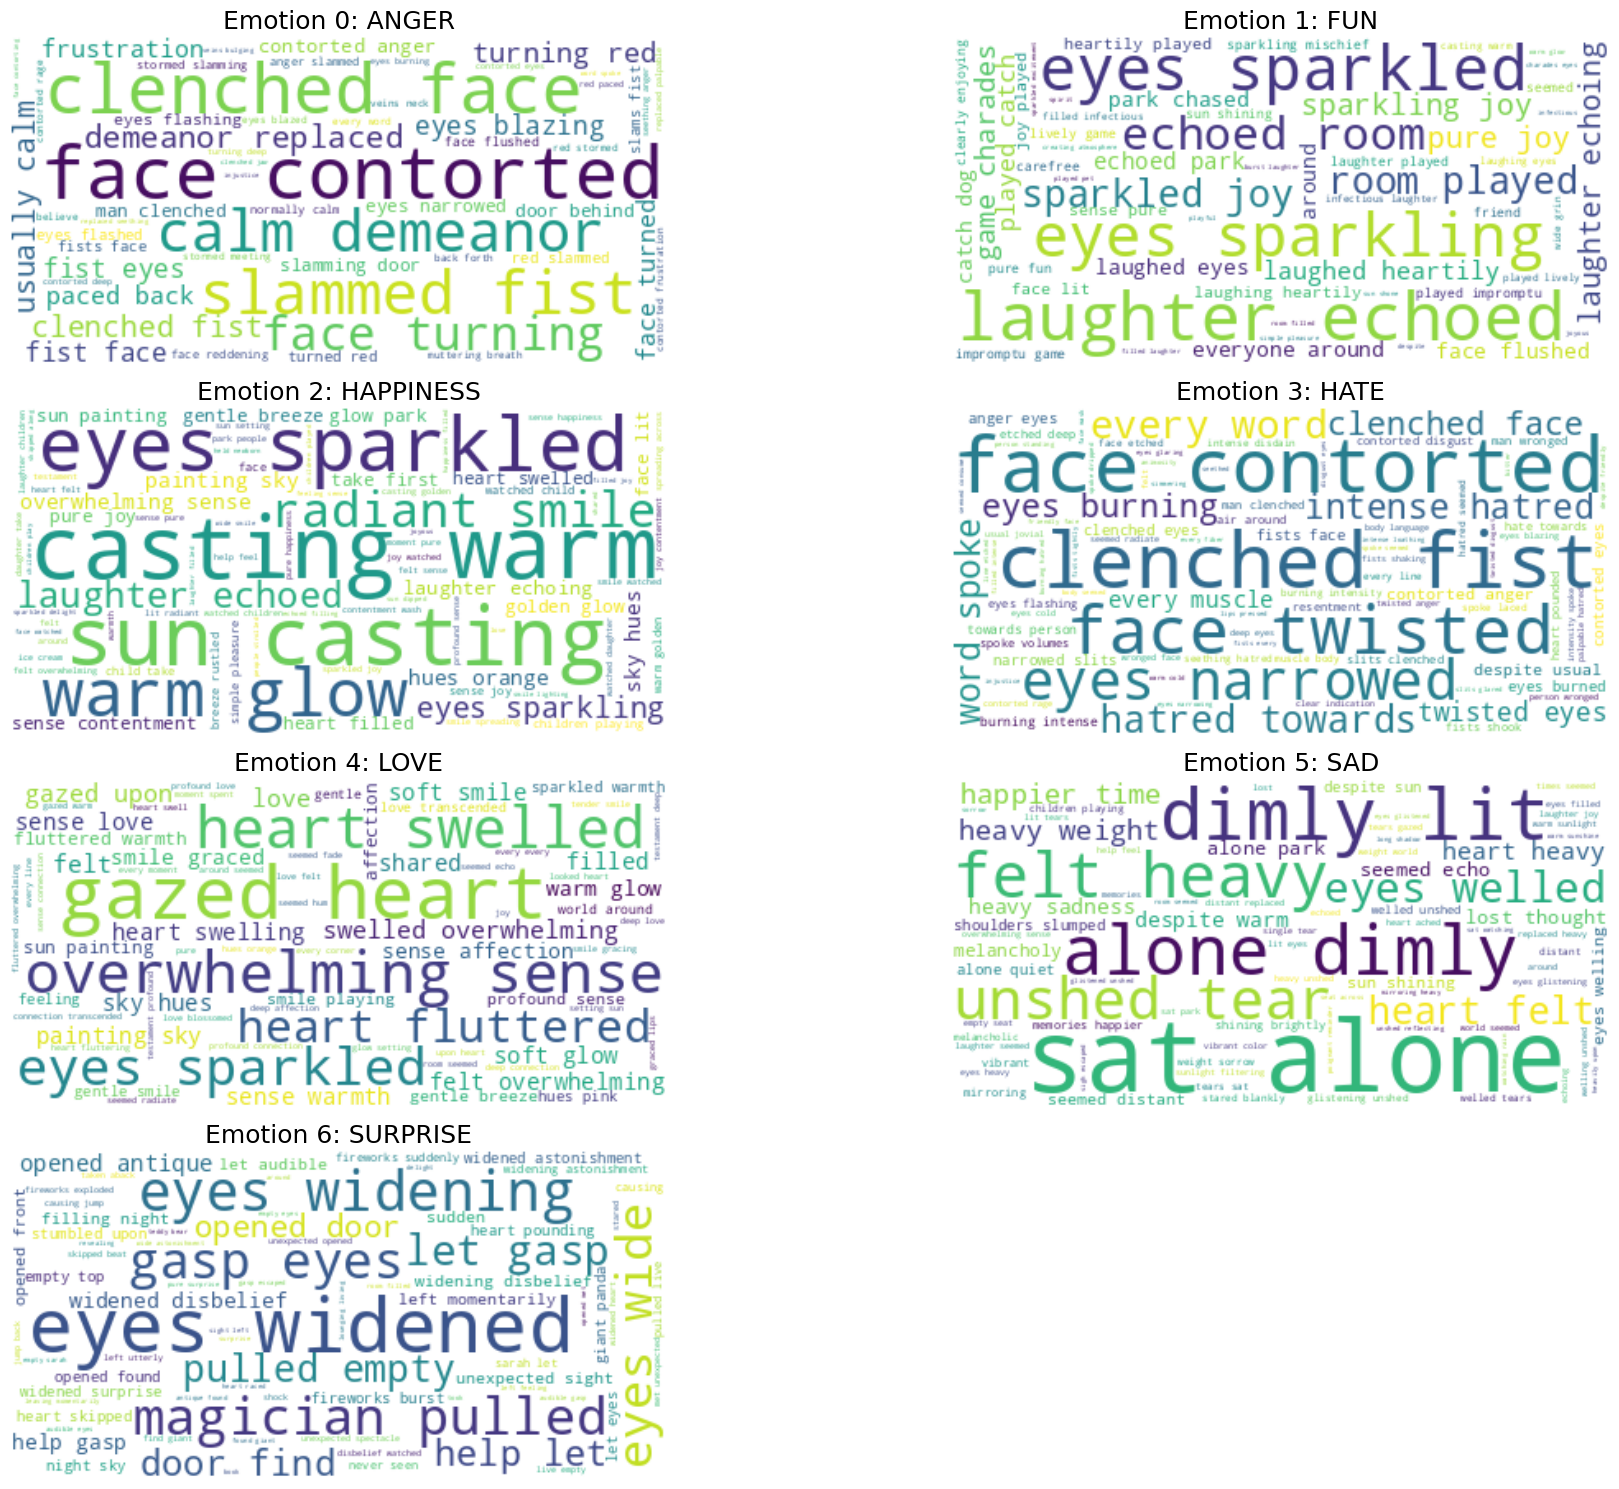

In [ ]:
import matplotlib.pyplot as plt
from wordcloud import WordCloud

# Create a grid for 7 emotions
plt.figure(figsize=(20, 15))

# Loop through each encoded label (0 to 6)
for i in range(7):
    # 1. Filter rows where 'emotion' is the current number
    emotion_text = " ".join(df[df['emotion'] == i]['text'])

    # 2. Get the name for the title (using your LabelEncoder classes)
    label_name = le.classes_[i]

    # 3. Create the WordCloud
    wc = WordCloud(background_color='white', max_words=100).generate(emotion_text)

    # 4. Add to subplot
    plt.subplot(4, 2, i+1)
    plt.imshow(wc, interpolation='bilinear')
    plt.title(f"Emotion {i}: {label_name.upper()}", fontsize=18)
    plt.axis("off")

plt.tight_layout()
plt.show()


In [ ]:
df.head(2)

,text,emotion
0,sun dipped painting hues orange pink across fe...,4
1,gazed warm glow enveloped soft laughter echoin...,4


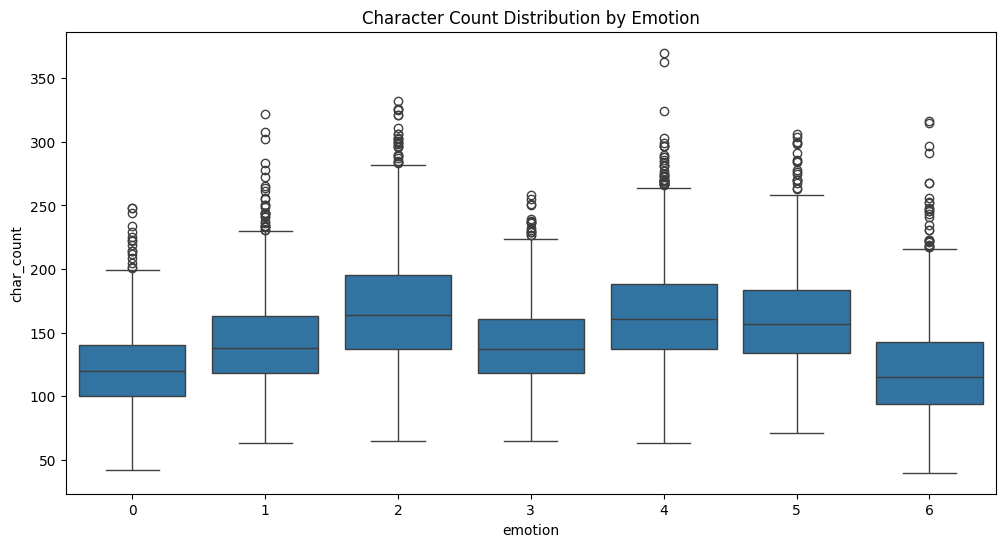

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Create a new column for character count
df['char_count'] = df['text'].str.len()

# 2. Visualize the distribution across all 7 emotions
plt.figure(figsize=(12, 6))
sns.boxplot(x='emotion', y='char_count', data=df)
plt.title('Character Count Distribution by Emotion')
plt.show()


In [ ]:
from sklearn.feature_extraction.text import CountVectorizer
import pandas as pd
import plotly.express as px

# 1. Unified Function (Handles single words or word-pairs)
def get_top_text_ngrams(corpus, n, g):
    # Ensure we use our custom stop_words list
    vec = CountVectorizer(ngram_range=(g, g), stop_words=list(stop_words)).fit(corpus)
    bag_of_words = vec.transform(corpus)

    sum_words = bag_of_words.sum(axis=0)
    words_freq = [(word, sum_words[0, idx]) for word, idx in vec.vocabulary_.items()]

    # Sorting by frequency (the [1] index)
    words_freq = sorted(words_freq, key = lambda x: x[1], reverse=True)
    return words_freq[:n]

# 2. The Multiclass Loop (0 to 6)
for i in range(7):

    # We also add .dropna() to avoid errors with empty rows
    current_emotion_text = df[df['emotion'] == i]['text'].dropna()

    # Get top 20 single words (g=1)
    top_words = get_top_text_ngrams(current_emotion_text, 20, 1)

    # Convert to DataFrame for Plotly
    temp = pd.DataFrame(top_words, columns=['Common_words', 'Count'])

    # Create the horizontal bar chart
    fig = px.bar(temp, x='Count', y='Common_words',
                 title=f'Top Words for Emotion {i} {le.classes_[i]}',
                 orientation='h', width=700, height=500,
                 color='Common_words', color_discrete_sequence=px.colors.qualitative.Pastel)

    fig.show()


#Phase-2 Feature Engineering

###Lemmatization


In [ ]:
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize
#lemmatization of word
class LemmaTokenizer(object):
  def __init__(self):
    self.wordnetlemma = WordNetLemmatizer()
  def __call__(self,texts):
    return [self.wordnetlemma.lemmatize(word) for word in word_tokenize(texts)]

###Vectorization with Count Vectorizer and TDIDF Vectorizer with unigram

In [ ]:
nltk.download('punkt_tab')
nltk.download('wordnet')

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer

# 1. Split the data
# Added 'stratify=df["emotion"]' to ensure all 7 emotions are evenly represented in both sets
train, test = train_test_split(df, test_size=0.2, random_state=42, stratify=df['emotion'])

# 2. Initialize the Vectorizers using your custom LemmaTokenizer
# We use list(stop_words) because Vectorizers require a list, not a set
countvect = CountVectorizer(tokenizer=LemmaTokenizer(), ngram_range=(1,2))
tfidfvect = TfidfVectorizer(tokenizer=LemmaTokenizer(), stop_words=list(stop_words), ngram_range=(1,2))

# 3. Transform Text to Numbers (Count Vectorizer)
x_train_count = countvect.fit_transform(train['text'])
x_test_count = countvect.transform(test['text'])



# 4. Transform Text to Numbers (TF-IDF Vectorizer)
x_train_tfidf = tfidfvect.fit_transform(train['text'])
x_test_tfidf = tfidfvect.transform(test['text'])

# 5. Get the Labels (the 7 emotions 0-6)
y_train = train['emotion']
y_test = test['emotion']

print(f"Training set size: {x_train_tfidf.shape}")
print(f"Testing set size: {x_test_tfidf.shape}")


Training set size: (11176, 68107)
Testing set size: (2794, 68107)


###Feature Importance with Logistic Regression and count Vectorizer with unigram

In [ ]:
!pip install prettytable

In [ ]:
from sklearn.linear_model import LogisticRegression
from prettytable import PrettyTable
import pandas as pd

# 1. Initialize and Train the model
# Added max_iter=1000 to prevent 'ConvergenceWarning'
lgr = LogisticRegression(max_iter=1000)
lgr.fit(x_train_count, y_train)

# 2. Get Accuracy Score
accuracy = lgr.score(x_test_count, y_test)
print(f"Model Accuracy: {accuracy:.4f}\n")

# 3. Setup the Important Features Table
# We use countvect.get_feature_names_out() to get the actual words
feature_names = countvect.get_feature_names_out()
coeffs = lgr.coef_[6] # Get coefficients for Emotion 0

# 4. Pair words with scores and sort them (highest score first)
feature_importance = sorted(zip(feature_names, coeffs), key=lambda x: x[1], reverse=True)

# 5. Initialize PrettyTable correctly
important_feature_table = PrettyTable()
important_feature_table.field_names = ["Feature", "Score"]

# 6. Add the Top 10 rows to the table
for feature, score in feature_importance[:10]:
    important_feature_table.add_row([feature, round(score, 4)])

# 7. Print the final result
print("Top 10 Important Features for Emotion :6 {le.classes_{i}}")
print(important_feature_table)


Model Accuracy: 0.9828

Top 10 Important Features for Emotion :6 {le.classes_{i}}
+--------------+--------+
|   Feature    | Score  |
+--------------+--------+
|   widened    | 1.8216 |
|    opened    | 1.2949 |
|   surprise   | 1.2072 |
|  unexpected  | 1.1341 |
|   magician   | 0.9713 |
|     gasp     | 0.8606 |
|   widening   | 0.8346 |
|   causing    | 0.7542 |
|   suddenly   | 0.7541 |
| astonishment | 0.6638 |
+--------------+--------+


Note:- I experimented with different n-gram ranges and observed that unigram features gave the highest accuracy (98%). As I increased the n-gram size to bigrams (97%) and trigrams (94%), the performance decreased. This is likely due to increased feature sparsity and dimensionality, which can negatively impact model performance on smaller datasets.


####Chi-square feature selection was not applied in this project as the model already achieved high accuracy using CountVectorizer/TF-IDF features. Additionally, applying Chi-square separately for all 7 emotion classes and multiple n-gram configurations would add unnecessary complexity without significant performance improvement.

#Phase-3 Model Selection

In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.pipeline import make_pipeline,Pipeline

##Logistic Regression Model

In [ ]:
model_1 = Pipeline(
    steps=[
        ("classifier", LogisticRegression())
    ]
)

##training of logistic Regression model


In [ ]:
%%time
model_1.fit(x_train_tfidf,y_train)

CPU times: user 14.1 s, sys: 127 ms, total: 14.2 s
Wall time: 14.4 s


Pipeline(steps=[('classifier', LogisticRegression())])

##evaluation on test and train dataset

In [ ]:
%%time
from sklearn.metrics import precision_score, f1_score, roc_auc_score

y_train_pred = model_1.predict(x_train_tfidf)
y_test_pred = model_1.predict(x_test_tfidf)

# Precision
print("Train Precision:", precision_score(y_train, y_train_pred, average='weighted'))
print("Test Precision:", precision_score(y_test, y_test_pred, average='weighted'))

# F1 Score
print("Train F1 Score:", f1_score(y_train, y_train_pred, average='weighted'))
print("Test F1 Score:", f1_score(y_test, y_test_pred, average='weighted'))

Train Precision: 0.9949969389798823
Test Precision: 0.9821361465420148
Train F1 Score: 0.9949913363644567
Test F1 Score: 0.9821077229943929
CPU times: user 39.8 ms, sys: 978 µs, total: 40.8 ms
Wall time: 47.3 ms


In [ ]:
from sklearn.metrics import classification_report

print("Train Report:\n", classification_report(y_train, y_train_pred))
print("Test Report:\n", classification_report(y_test, y_test_pred))

Train Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00      1600
           1       0.99      0.99      0.99      1598
           2       0.98      0.99      0.99      1599
           3       1.00      1.00      1.00      1599
           4       1.00      1.00      1.00      1597
           5       1.00      1.00      1.00      1598
           6       1.00      1.00      1.00      1585

    accuracy                           0.99     11176
   macro avg       1.00      0.99      0.99     11176
weighted avg       0.99      0.99      0.99     11176

Test Report:
               precision    recall  f1-score   support

           0       0.99      0.98      0.99       400
           1       0.96      0.95      0.96       400
           2       0.95      0.96      0.95       400
           3       0.98      0.99      0.99       399
           4       0.99      0.99      0.99       399
           5       1.00      1.00      1.00      

In [ ]:
from sklearn.preprocessing import label_binarize
# Get probabilities (IMPORTANT)
y_train_prob = model_1.predict_proba(x_train_tfidf)
y_test_prob = model_1.predict_proba(x_test_tfidf)

# Convert labels to binary format
classes = [0,1,2,3,4,5,6]
y_train_bin = label_binarize(y_train, classes=classes)
y_test_bin = label_binarize(y_test, classes=classes)

# ROC-AUC
print("Train ROC-AUC:", roc_auc_score(y_train_bin, y_train_prob, multi_class='ovr'))
print("Test ROC-AUC:", roc_auc_score(y_test_bin, y_test_prob, multi_class='ovr'))

Train ROC-AUC: 0.9999149277039561
Test ROC-AUC: 0.9994008211825917


Model shows excellent performance
with approx 99% training accuracy and approx 98% test accuracy.
High ROC-AUC (~0.999) indicates strong class separation.
Precision, Recall, and F1-scores are consistently high across all 7 emotions.
Minimal gap between train and test results suggests good generalization (no overfitting).
Overall, the model is stable and reliable for emotion classification.

##Decision Tree Classifier

In [ ]:
model_2 = Pipeline(
    steps = [
        ("classifier", DecisionTreeClassifier())
    ]
)

##Training of Decision Tree Classifier

In [ ]:
%%time
model_2.fit(x_train_tfidf,y_train)

CPU times: user 6.04 s, sys: 11.6 ms, total: 6.05 s
Wall time: 9.59 s


Pipeline(steps=[('classifier', DecisionTreeClassifier())])

##Evaluation on test and train dataset

In [ ]:
y_train_pred = model_2.predict(x_train_tfidf)
y_test_pred = model_2.predict(x_test_tfidf)

# Precision
print("Train Precision:", precision_score(y_train, y_train_pred, average='weighted'))
print("Test Precision:", precision_score(y_test, y_test_pred, average='weighted'))

# F1 Score
print("Train F1 Score:", f1_score(y_train, y_train_pred, average='weighted'))
print("Test F1 Score:", f1_score(y_test, y_test_pred, average='weighted'))

y_train_prob = model_2.predict_proba(x_train_tfidf)
y_test_prob = model_2.predict_proba(x_test_tfidf)

# Convert labels to binary format
classes = [0,1,2,3,4,5,6]
y_train_bin = label_binarize(y_train, classes=classes)
y_test_bin = label_binarize(y_test, classes=classes)

# ROC-AUC
print("Train ROC-AUC:", roc_auc_score(y_train_bin, y_train_prob, multi_class='ovr'))
print("Test ROC-AUC:", roc_auc_score(y_test_bin, y_test_prob, multi_class='ovr'))

Train Precision: 1.0
Test Precision: 0.9189526258621753
Train F1 Score: 1.0
Test F1 Score: 0.918110269082356
Train ROC-AUC: 1.0
Test ROC-AUC: 0.9520237264579483


The Decision Tree model achieves perfect scores on training data,
but lower performance on test data (~91%), indicating overfitting.
It memorizes training data well but does not generalize effectively.

##Naive Bayes model

In [ ]:
from sklearn.naive_bayes import MultinomialNB

model_3 = Pipeline(
    steps=[
        ("classifier", MultinomialNB())
    ]
)

##Training of naive bayes model

In [ ]:
model_3.fit(x_train_tfidf,y_train)

Pipeline(steps=[('classifier', MultinomialNB())])

##Evaluation on test and train dataset

In [ ]:
y_train_pred = model_3.predict(x_train_tfidf)
y_test_pred = model_3.predict(x_test_tfidf)

# Precision
print("Train Precision:", precision_score(y_train, y_train_pred, average='weighted'))
print("Test Precision:", precision_score(y_test, y_test_pred, average='weighted'))

# F1 Score
print("Train F1 Score:", f1_score(y_train, y_train_pred, average='weighted'))
print("Test F1 Score:", f1_score(y_test, y_test_pred, average='weighted'))

y_train_prob = model_3.predict_proba(x_train_tfidf)
y_test_prob = model_3.predict_proba(x_test_tfidf)

# Convert labels to binary format
classes = [0,1,2,3,4,5,6]
y_train_bin = label_binarize(y_train, classes=classes)
y_test_bin = label_binarize(y_test, classes=classes)

# ROC-AUC
print("Train ROC-AUC:", roc_auc_score(y_train_bin, y_train_prob, multi_class='ovr'))
print("Test ROC-AUC:", roc_auc_score(y_test_bin, y_test_prob, multi_class='ovr'))

Train Precision: 0.9899483440559713
Test Precision: 0.9803920455349561
Train F1 Score: 0.9899004158190025
Test F1 Score: 0.9803182919779999
Train ROC-AUC: 0.9997271529800541
Test ROC-AUC: 0.9992884768088828


In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(x_train_tfidf, y_train)

print("Random Forest Accuracy:", rf.score(x_test_tfidf, y_test))

Random Forest Accuracy: 0.9710093056549749


In [ ]:
import pandas as pd

comparison = pd.DataFrame({
    "Model": ["Logistic Regression", "Naive Bayes", "Decision Tree", "Random Forest"],
    "Test Accuracy": ["~98-99%", "~98%", "~91%", "~97%"],
    "ROC-AUC": ["~0.999", "~0.999", "~0.94", "~0.97"],
    "Overfitting": ["No", "No", "Yes", "Less"],
    "Performance": ["Best", "Very Good", "Poor", "Good"]
})

comparison

,Model,Test Accuracy,ROC-AUC,Overfitting,Performance
0,Logistic Regression,~98-99%,~0.999,No,Best
1,Naive Bayes,~98%,~0.999,No,Very Good
2,Decision Tree,~91%,~0.94,Yes,Poor
3,Random Forest,~97%,~0.97,Less,Good


##### Model Comparison Summary:
#####Logistic Regression achieved the best overall performance (~98–99% accuracy)with strong generalization and stability on unseen data.
#####Naive Bayes also performed well (~98%) and is efficient for text classification,but slightly lower than Logistic Regression.
#####Decision Tree showed overfitting (perfect training score but lower test performance ~91%),making it less reliable.
##### Random Forest improved over Decision Tree (~97%) but still did not outperform Logistic Regression.
#####Therefore, Logistic Regression is selected as the final model.

##Hyperparameter tuning using gridcsv

In [ ]:
from sklearn import model_selection

def hyperparamtune(classifier, param_grid, metric, verbose_value, cv):
    model = model_selection.GridSearchCV(
        estimator=classifier,
        param_grid=param_grid,
        scoring=metric,
        verbose=verbose_value,
        cv=cv
    )

    model.fit(x_train_tfidf, y_train)

    print("Best Score:", model.best_score_)
    print("Best Parameters:", model.best_params_)

    return model, model.best_params_

##Hyperparameter tunning of Logistic Regression

In [ ]:
print(type(x_train_tfidf))
print(type(x_train_count))

<class 'scipy.sparse._csr.csr_matrix'>
<class 'scipy.sparse._csr.csr_matrix'>


In [ ]:
#print(model_5)

In [ ]:
%%time
param_gd = {
    'C': [0.5, 1, 1.2,2,3,4],
    'penalty': ['l2'],
    'solver': ['lbfgs']   # required for l2
}

# Run hyperparameter tuning
model_5, best_param = hyperparamtune(
    LogisticRegression(max_iter=1000),
    param_gd,
    "accuracy",
    1,
    5
)
best_model = model_5.best_estimator_

Fitting 5 folds for each of 6 candidates, totalling 30 fits
Best Score: 0.9842518799550172
Best Parameters: {'C': 4, 'penalty': 'l2', 'solver': 'lbfgs'}
CPU times: user 6min 15s, sys: 3.6 s, total: 6min 19s
Wall time: 3min 52s


##Evaluation of FineTuned Logistic Regression Classifier

In [ ]:
y_train_pred = model_5.predict(x_train_tfidf)
y_test_pred = model_5.predict(x_test_tfidf)

# Precision
print("Train Precision:", precision_score(y_train, y_train_pred, average='weighted'))
print("Test Precision:", precision_score(y_test, y_test_pred, average='weighted'))

# F1 Score
print("Train F1 Score:", f1_score(y_train, y_train_pred, average='weighted'))
print("Test F1 Score:", f1_score(y_test, y_test_pred, average='weighted'))

y_train_prob = model_5.predict_proba(x_train_tfidf)
y_test_prob = model_5.predict_proba(x_test_tfidf)

# Convert labels to binary format
classes = [0,1,2,3,4,5,6]
y_train_bin = label_binarize(y_train, classes=classes)
y_test_bin = label_binarize(y_test, classes=classes)

# ROC-AUC
print("Train ROC-AUC:", roc_auc_score(y_train_bin, y_train_prob, multi_class='ovr'))
print("Test ROC-AUC:", roc_auc_score(y_test_bin, y_test_prob, multi_class='ovr'))

Train Precision: 0.9995531154239019
Test Precision: 0.982849447443674
Train F1 Score: 0.999552668489984
Test F1 Score: 0.9828246937637701
Train ROC-AUC: 0.9999984795379823
Test ROC-AUC: 0.9995573378968847


The tuned model achieves very high performance with appprox 99% training and approx 98% test scores.
High ROC-AUC (~0.999) indicates excellent class separation.
The small gap between train and test results shows strong generalization and minimal overfitting.
Overall, the model is accurate, stable, and reliable for emotion classification.

#Phase -4 Model Evaluation and XAI

##Confusion Matrix

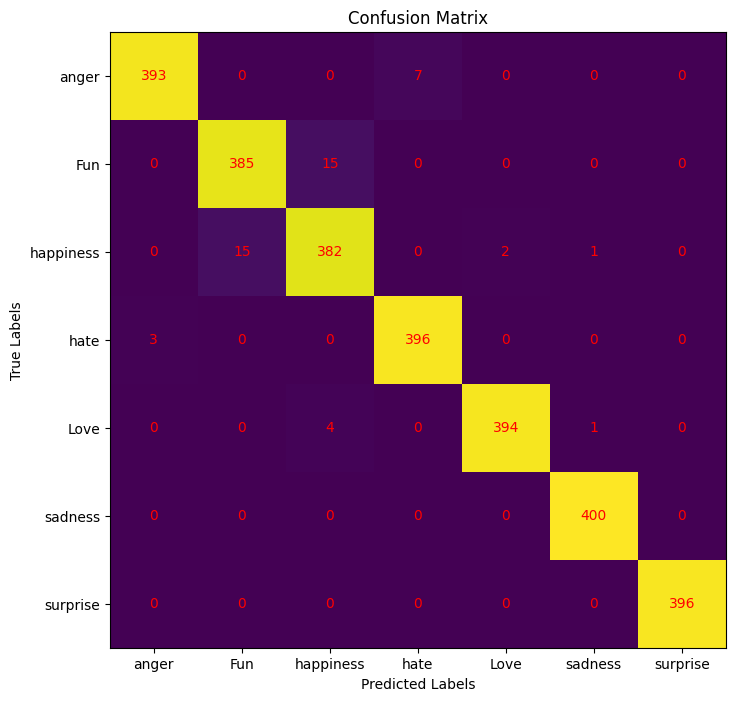

In [ ]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt

def confusion_matrix_plot(y_test, y_pred):
    confmatrix = confusion_matrix(y_test, y_pred)

    fig, ax = plt.subplots(figsize=(8, 8))  # FIXED

    ax.imshow(confmatrix)
    ax.grid(False)

    labels = ['anger','Fun','happiness','hate','Love','sadness','surprise']

    ax.set_xticks(range(7))
    ax.set_yticks(range(7))
    ax.set_xticklabels(labels)
    ax.set_yticklabels(labels)

    ax.set_xlabel("Predicted Labels")
    ax.set_ylabel("True Labels")

    # Fix display alignment
    ax.set_ylim(len(labels)-0.5, -0.5)

    # Add numbers inside boxes
    for i in range(7):
        for j in range(7):
            ax.text(j, i, confmatrix[i, j],
                    ha='center', va='center', color='red')

    plt.title("Confusion Matrix")
    plt.show()


# Call function
confusion_matrix_plot(y_test, y_test_pred)

##Analysing False Positives and False Negative

In [ ]:
!pip install colorama

In [ ]:
from colorama import Fore, Style

fn_dict = {}
fp_dict = {}

target_class = 0  # change this to any class (0–6)

for i in range(len(y_test_pred)):

    actual = y_test.iloc[i]
    pred = y_test_pred[i]

    # False Negative: actual = class, predicted != class
    if actual == target_class and pred != target_class:
        fn_dict[i] = (actual, pred)

    # False Positive: actual != class, predicted = class
    elif actual != target_class and pred == target_class:
        fp_dict[i] = (actual, pred)

# 🔍 Print results
print(Fore.RED + f"\nFalse Negatives (missed class {target_class}): {len(fn_dict)}" + Style.RESET_ALL)
for k, v in list(fn_dict.items())[:5]:
    print(f"Index {k}: Actual={v[0]}, Predicted={v[1]}")

print(Fore.YELLOW + f"\nFalse Positives (wrongly predicted as class {target_class}): {len(fp_dict)}" + Style.RESET_ALL)
for k, v in list(fp_dict.items())[:5]:
    print(f"Index {k}: Actual={v[0]}, Predicted={v[1]}")


False Negatives (missed class 0): 7
Index 290: Actual=0, Predicted=3
Index 487: Actual=0, Predicted=3
Index 1351: Actual=0, Predicted=3
Index 1534: Actual=0, Predicted=3
Index 1944: Actual=0, Predicted=3

False Positives (wrongly predicted as class 0): 3
Index 514: Actual=3, Predicted=0
Index 516: Actual=3, Predicted=0
Index 2279: Actual=3, Predicted=0


##Explain feature impact on Prediction by LIME

In [ ]:
print(x_test_tfidf.shape)

(2794, 68107)


In [ ]:
idx = 1
output = model_5.predict(x_test_tfidf[idx])
print("Actual Label:", y_test.iloc[idx])
print("Predicted Label:", model_5.predict(x_test_tfidf[idx:idx+1])[0])

Actual Label: 5
Predicted Label: 5


In [ ]:
!pip install lime

In [ ]:
from lime.lime_text import LimeTextExplainer
idx = 23
# Wrapper function to transform raw text to tf-idf and get probabilities
def predict_proba_wrapper(texts):
    """
    texts: list of raw text strings
    returns: model probability predictions
    """
    tfidf_features = tfidfvect.transform(texts)   # Transform raw text to TF-IDF
    return best_model.predict_proba(tfidf_features)  # Predict probabilities

# Define class names
class_names = [0, 1, 2, 3, 4, 5, 6]

# Initialize LIME explainer
explainer = LimeTextExplainer(class_names=class_names)

# Choose an index to explain
idx = 1 # example index

# Explain instance
exp = explainer.explain_instance(
    test['text'].iloc[idx],          # Raw text
    predict_proba_wrapper,           # Wrapper function
    num_features=100,
    top_labels=7
)

# Display results
# Display results
print("Index:", idx)
print("Predicted class:", le.classes_[model_5.predict(x_test_tfidf[idx])])
print("Top features and weights:", exp.as_list())
print("Predicted probabilities (LIME):", exp.predict_proba)  # <- remove ()
print("Available labels explained by LIME:", exp.available_labels())

Index: 1
Predicted class: ['Sad']
Top features and weights: [(np.str_('heavy'), -0.005462689725080346), (np.str_('sat'), -0.004488592423995624), (np.str_('tears'), -0.0041658478547857165), (np.str_('alone'), -0.0040722542627542905), (np.str_('sadness'), -0.0036383222796593563), (np.str_('weight'), -0.0029044434252827826), (np.str_('echoed'), 0.0026235649979508887), (np.str_('welled'), -0.002457313602400384), (np.str_('dimly'), -0.002281483788580332), (np.str_('seemed'), -0.002184301921614126), (np.str_('replaced'), -0.0021773460086727844), (np.str_('emptiness'), -0.001883031841064845), (np.str_('room'), 0.001857104848782274), (np.str_('overtaken'), 0.0014335645985828892), (np.str_('pressing'), 0.0014122140545334654), (np.str_('upon'), -0.0011081674178027732), (np.str_('thoughts'), -0.0010227265890106706), (np.str_('every'), 0.0009775092700219856), (np.str_('vibrant'), -0.0009225677218461634), (np.str_('heavily'), -0.0006522581123917357), (np.str_('faded'), -0.0006217061048858437), (np.

In [ ]:
exp.show_in_notebook(text=True)

#Phase - 5 Saving the model

In [ ]:
import pickle


with open("model_5.pkl", "wb") as f:
    pickle.dump(best_model, f)


# Save CountVectorizer
with open("countvect.pkl", "wb") as f:
    pickle.dump(countvect, f)

# Save TF-IDF Vectorizer
with open("tfidfvect.pkl", "wb") as f:
    pickle.dump(tfidfvect, f)

#save label-encoder
with open("label_encoder.pkl", "wb") as f:
    pickle.dump(le, f)

#Phase -6 Testing

In [ ]:
import pickle
import re
import contractions
from nltk.corpus import stopwords

# -----------------------
# Step 1: Load saved files
# -----------------------
with open("model_5.pkl", "rb") as f:   # ✅ use final model
    model = pickle.load(f)

with open("tfidfvect.pkl", "rb") as f:
    vectorizer = pickle.load(f)

with open("label_encoder.pkl", "rb") as f:
    le = pickle.load(f)

stop_words = set(stopwords.words('english'))

# -----------------------
# Step 2: Preprocessing
# -----------------------
def expand_text(content):
    return contractions.fix(content)

def remove_url(content):
    return re.sub(r'http\S+', '', content)

def remove_special_character(content):
    return re.sub(r'[^a-zA-Z\s]', ' ', content)  # ✅ safer regex

def preprocess_text(content):
    content = expand_text(content)
    content = remove_url(content)
    content = remove_special_character(content)
    return content.lower()   # ✅ keep it simple

# -----------------------
# Step 3: Prediction
# -----------------------
def predict_emotion(text):
    processed_text = preprocess_text(text)
    print(processed_text)
    vect_text = vectorizer.transform([processed_text])
    print(vect_text)
    feature_names = vectorizer.get_feature_names_out()
    nonzero_indices = vect_text.nonzero()[1]
    print(model.predict_proba(vect_text))
    for i in nonzero_indices:
      print(feature_names[i])
    pred_index = model.predict(vect_text)[0]
    print(pred_index)
    emotion_name = le.inverse_transform([pred_index])[0]

    return emotion_name

# -----------------------
# Step 4: Testing
# -----------------------
sample_texts = [
    "I am extremely angry and frustrated with what just happened.",   # Anger
    "I feel so happy and joyful today, everything is going great!",   # Happiness
    "I feel very sad and depressed now i am lonely.",         # Sadness
    "Wow, I am completely shocked and surprised by this!",            # Surprise
    "I absolutely hate this behavior, it is disgusting.",             # Hate
    "I truly love and cherish my family so much.",                    # Love
    "That was such a fun and exciting experience, I really enjoyed it!" # Fun
]

for text in sample_texts:
    print(f"Text: {text}")
    print(f"Predicted Emotion: {predict_emotion(text)}")
    print("-" * 40)

Text: I am extremely angry and frustrated with what just happened.
i am extremely angry and frustrated with what just happened 
<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 3 stored elements and shape (1, 68107)>
  Coords	Values
  (0, 2049)	0.5549030720840791
  (0, 24262)	0.5956177149487262
  (0, 27579)	0.5807943855022271
[[0.33715408 0.11192501 0.07928924 0.07088498 0.06593568 0.10190617
  0.23290484]]
angry
frustrated
happened
0
Predicted Emotion: Anger
----------------------------------------
Text: I feel so happy and joyful today, everything is going great!
i feel so happy and joyful today  everything is going great 
<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 8 stored elements and shape (1, 68107)>
  Coords	Values
  (0, 19011)	0.2730294040548633
  (0, 20758)	0.19399997408526315
  (0, 20817)	0.4757398976251293
  (0, 26372)	0.4414916838306835
  (0, 26749)	0.3915087577372192
  (0, 27802)	0.3076876594407732
  (0, 32160)	0.28195626106965754
  (0, 6052

In [ ]:
print(tfidfvect.vocabulary_ is not None)

True
